# Sentiment Analysis of Twitter US Airline 

**Date:** 8 May 2026

**Student Name:** Alya Alalwan

**Student ID:** G240001714

**CRN:** 20099

**Course Code:** DS-560 

**Course Name:** Advanced Data Mining 

**Assessment type:** Critical Thinking #3

**Assessment Total Marks:** 100


# Table of Contents

1. Dataset Description
2. Import Libraries
3. Load Dataset as Dataframe
4. Data Exploration
5. Data Cleaning and Pre-processing
6. Sentiment Analysis
7. Create Sentiment DataFrame

# Dataset Description

The dataset was used in this project is Twitter US Airline Sentiment dataset obtained from Kaggle. It includes travelers' opinions about US airlines posted in Twitter platform in February 2015. This dataset usually used in sentiment analysis tasks in order to study travelers' opinions expressed in text form. It contains 14,640 records where each record represents a single tweet posted by a traveler and labeled according to their sentiment as positive, negative, or neutral. Also, the dataset contains 15 features:


-	tweet_id: a unique identifier assigned to each tweet
-	airline_sentiment: involves sentiment labeling for each tweet: positive, negative, or neutral
-	airline_sentiment_confidence: involves confidence score of the sentiment classification
-	Negativereason: includes reason associated with negative tweets 
-	negativereason_confidence: involves confidence score of the negative reason classification
-	airline: name of the airline 
-	airline_sentiment_gold: human-verified sentiment label
-	name: twitter username of the person who posted the tweet
-	negativereason_gold: human-verified negative reason label 
-	retweet_count: number of times the tweet was retweeted
-	text: actual tweet text written by the user
-	tweet_coord: geographic coordinates of the tweet 
-	tweet_created: date and time when the tweet was posted
-	tweet_location: geographic location reported by the user
-	user_timezone: Time zone associated with the user

# Import Libraries

Several Python libraries were imported:
- **pandas** library was imported to support loading and handling the dataset in dataframe format
- **numpy**  library was imported to support numerical operations
- **re** library was imported to clean textual data and remvoing unnecessary elements 
- **TextBlob** library was imported for tweet sentiment polarity estimation and sentiment classification
- **matplotlib.pyplot** and **seaborn** libraries were imported to create important visualizations for exploring the dataset

In [9]:
# Import libraries
import pandas as pd
import numpy as np
import re
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset as Dataframe

`read_csv()` function was used to load Twitter US Airline Sentiment dataset as dataframe using pandas library. After successfully loading the dataset, the `head()` function was used to display the head of dataset to provide a brief preview of the dataset structure and understand its variables.

In [11]:
# Load dataset
twt_df = pd.read_csv('Tweets.csv')

# Display the head of dataset
twt_df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


# Data Exploration

multiple exploratory steps were done to examine dataset and understand its structure and quality before applying data preprocessing and sentiment analysis techniques. The following exploratory steps were performed:
- `shape` attribute was used to extract the number of records and variables within dataset
- `info()` function was used to display important information such as number of column and its names, the number of non-null values, and datatype for each variable
- `isnull().sum()` function was used to detect incomplete data per column
- `duplicated().sum()` function was used to examine repeated tweets within the dataset
-  `describe()` function was used to extract descriptive statistics for specific categorical variables including airline sentiment, airline name, and negative reason. Other variables were not included because they mainly contain identifiers, metadata that provide limited value for sentiment analysis exploration
- `countplot()` function was used to explore the distribution of tweet sentiments as well as negative reasons associated with tweets. These visualizations are important because they help in understanding the frequency of sentiment categories within the dataset and identifying the most common customer complaints reported by airline passengers.

Dataset Shape: (14640, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_creat

,airline_sentiment,airline,negativereason
count,14640,14640,9178
unique,3,6,10
top,negative,United,Customer Service Issue
freq,9178,3822,2910


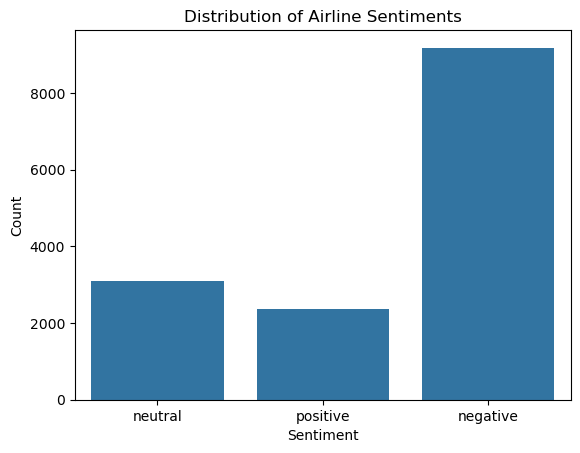

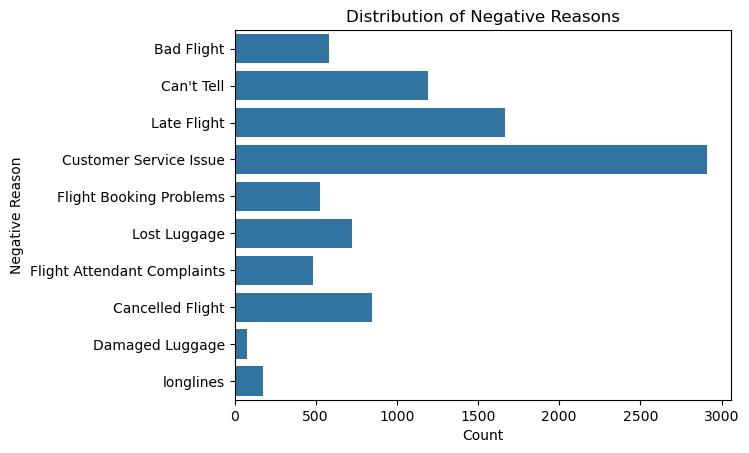

In [13]:
# Display dataset shape
print ("Dataset Shape:", twt_df.shape)

# Display dataset information 
print("\nDataset Information:")
print(twt_df.info())

# Check missing values per column
print("\nMissing Vaules:")
print(twt_df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", twt_df.duplicated().sum())


# Display descriptive statistics for categorical columns
display(twt_df[['airline_sentiment', 'airline', 'negativereason']].describe())

# Sentiment distribution
sns.countplot(x='airline_sentiment', data=twt_df)
plt.title('Distribution of Airline Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Negative reason distribution
sns.countplot(y='negativereason', data=twt_df)
plt.title('Distribution of Negative Reasons')
plt.xlabel('Count')
plt.ylabel('Negative Reason')
plt.show()

# Data Cleaning and Pre-processing

Dataset undergoes several preprocessing techniques to prepare tweet text for sentiment analysis. The following preprocessing techniques were applied:

- duplicate records were removed using `drop_duplicates()` function to avoid repeated records that may affect the analysis results.
- a custom function was created called `clean_twt()` to preprocess tweet text by removing  mentions, URLs, hashtag symbols, numbers, special characters, and extra white spaces from tweets. To improve text consistency during sentiment analysis, all tweet text was converted to lowercase using `lower()`.

Then, cleaned tweets were stored in a new column called `cleaned_tweet` while keeping the original tweet text in the `text` column. Finally, the cleaned dataset was re-checked by obtaining dataset shape, duplicate records, and the head of the dataset after preprocessing.

In [15]:
# Drop duplicate records
twt_df.drop_duplicates(inplace=True)

# Creat function to clean text in tweet
def clean_twt(tweet):
    #Remove mentions
    tweet = re.sub(r'@\w+', '', tweet)
    
    # Remove URLs
    tweet = re.sub(r'http\S+|www\S+', '', tweet)
    
    # Remove # symbol 
    tweet = re.sub(r'#', '', tweet)
    
    # Remove numbers and special characters
    tweet = re.sub(r'[^A-Za-z\s]', '', tweet)
    
    # Convert whole text to lowercase
    tweet = tweet.lower()
    # Remove extra white spaces
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    
    return tweet

# Apply clean text function on text coulmn and store it in separate coulmn   
twt_df['cleaned_tweet'] = twt_df['text'].apply(clean_twt)

# Check the shape of dataset after cleaning
print("Dataset Shape After Cleaning:", twt_df.shape)

# Check the duplicate records in dataset after cleaning
print("\nDuplicate Records After Cleaning:", twt_df.duplicated().sum())

# Display head of dataset after cleaning
twt_df.head()

Dataset Shape After Cleaning: (14604, 16)

Duplicate Records After Cleaning: 0


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,cleaned_tweet
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),what said
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),plus youve added commercials to the experience...
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),i didnt today must mean i need to take another...
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),its really aggressive to blast obnoxious enter...
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),and its a really big bad thing about it


# Sentiment Analysis

Custom function called `estimate_sentiment()` was created in order to classify tweet sentiments based on sentiment polarity scores generated with help of the `TextBlob` library. The `TextBlob().sentiment.polarity` function was used to estimate the polarity of each cleaned tweet based on the following:
- Polarity values greater than 0 were classified as positive
- Polarity values less than 0 were classified as negative
- polarity values equal to 0 were classified as neutral

After that, sentiment analysis was performed on the `cleaned_tweet` column using the `apply()` function, where the result of analysis for each tweet was stored in a new column called `estimated_sentiment`. 

In [17]:
#  Create function for sentiment classification
def estimate_sentiment(tweet):
    polarity = TextBlob(tweet).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

# perform sentiment analysis
twt_df['estimated_sentiment'] = twt_df['cleaned_tweet'].apply(estimate_sentiment)

# Create Sentiment DataFrame

Now, new dataframe was created and called `sentiment_analysis_df` to store only the cleaned tweet text and its associated estimated sentiment. Then, both columns were renamed to `Tweet` and `Associated_Sentiment` to make the final output easier to understand. Finally, the `head()` function was used to display the head of sentiment analysis dataframe.

In [19]:
# Create a new dataframe to store 'cleaned_tweet' and 'estimated_sentiment'
sentiment_analysis_df = twt_df[['cleaned_tweet', 'estimated_sentiment']]

# Rename columns
sentiment_analysis_df.columns = ['Tweet', 'Associated_Sentiment']

# Display head of new dataframe
sentiment_analysis_df.head()

,Tweet,Associated_Sentiment
0,what said,Neutral
1,plus youve added commercials to the experience...,Neutral
2,i didnt today must mean i need to take another...,Negative
3,its really aggressive to blast obnoxious enter...,Positive
4,and its a really big bad thing about it,Negative
